# 03 - Bayesian MCMC

Goal of this notebook: instead of the single `(c_hat, k_hat)` point estimate from notebook 02, recover full posterior distributions over `(c, k, sigma)` via Markov Chain Monte Carlo. This gives calibrated uncertainty on the recovered parameters -- and, unlike least-squares, an honest answer to "how much should I trust this estimate?" that gets *worse* in a visible way as noise increases, rather than silently returning a point estimate at any noise level.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from simulate import OscillatorParams, simulate
from noise import NoiseConfig, corrupt_trajectory
from fit_leastsquares import fit_leastsquares
from fit_mcmc import fit_mcmc, forward_model, summarize

## Ground truth system

Same system and same noisy dataset as notebook 02, so the least-squares and MCMC results are directly comparable.

In [2]:
true_params = OscillatorParams(m=1.0, c=0.3, k=4.0)
x0, v0 = 1.0, 0.0
t, x_clean, v_clean = simulate(true_params, x0, v0, t_span=(0, 20), n_points=300)

config = NoiseConfig(sigma=0.1, missing_frac=0.05, seed=42)
t_obs, x_obs = corrupt_trajectory(t, x_clean, config)
print(f'observed {len(t_obs)} of {len(t)} original samples')

observed 283 of 300 original samples


## Least-squares baseline (from notebook 02)

Recomputed here to (a) initialize the MCMC walkers in a sensible region and (b) give a point-estimate anchor to compare the posterior against later.

In [3]:
c_ls, k_ls, ls_result = fit_leastsquares(t_obs, x_obs, x0, v0)
print(f'least-squares: c={c_ls:.4f} (true: {true_params.c}), k={k_ls:.4f} (true: {true_params.k})')

least-squares: c=0.3009 (true: 0.3), k=4.0221 (true: 4.0)


## Model

`theta = [c, k, log_sigma]`. Unlike the least-squares fit, the measurement noise level `sigma` is treated as an unknown to be inferred jointly with `(c, k)`, rather than assumed known -- in a real experiment you wouldn't know your sensor noise ahead of time either. Priors are weakly informative: `c ~ Uniform(0, 10)`, `k ~ Uniform(1e-6, 20)`, `log_sigma ~ Uniform(log(1e-4), log(2.0))`, just enough to keep the sampler in a physically sensible region. Full details (log-prior, log-likelihood, the Metropolis-Hastings sampler itself) are in `fit_mcmc.py`.

## Run the sampler

In [4]:
samples, chain, acc_frac = fit_mcmc(
    t_obs, x_obs, x0, v0,
    init_guess=(c_ls, k_ls, np.log(0.1)),
    step_size=(0.007, 0.013, 0.038),  # tuned by hand for a ~0.2-0.5 acceptance fraction
    n_steps=50000,
    burn_in=5000,
    seed=0,
)

print(f'acceptance fraction: {acc_frac:.3f}  (healthy range is roughly 0.2-0.5)')
print()
summarize(samples)

acceptance fraction: 0.513  (healthy range is roughly 0.2-0.5)

c: 0.3015  (+0.0083 / -0.0080)  [68% CI]
k: 4.0223  (+0.0164 / -0.0163)  [68% CI]
sigma: 0.0914  (+0.0040 / -0.0037)  [68% CI]


## Convergence check: trace plot

The chain's `(c, k, log_sigma)` over the run. Should look like a "fuzzy caterpillar" with no drift or wandering -- if the chain is still trending toward the bulk of the posterior well past the burn-in cutoff, it hasn't converged and `n_steps`/`burn_in` need to increase.

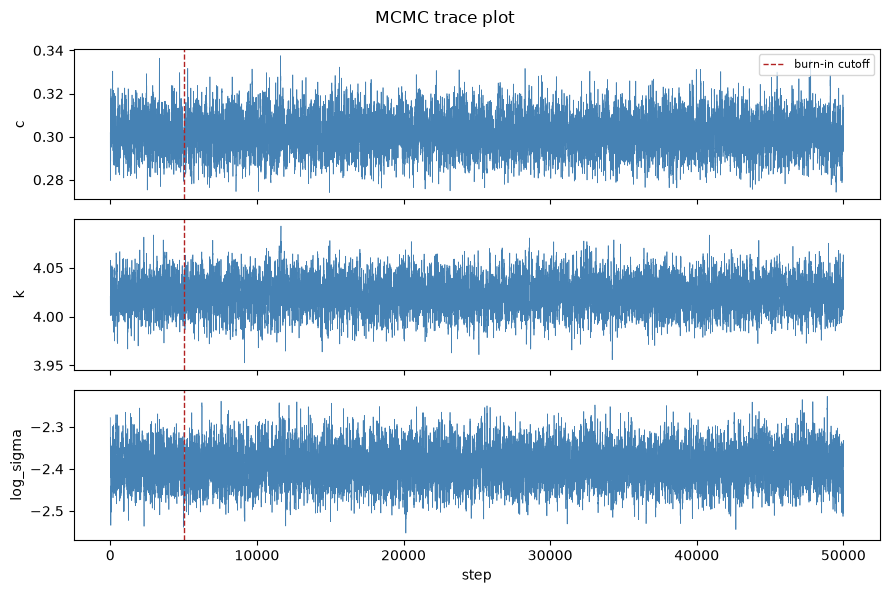

In [5]:
names = ['c', 'k', 'log_sigma']
burn_in = 5000

fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(chain[:, i], color='steelblue', lw=0.5)
    ax.axvline(burn_in, color='firebrick', ls='--', lw=1, label='burn-in cutoff')
    ax.set_ylabel(names[i])
    if i == 0:
        ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('step')
fig.suptitle('MCMC trace plot')
plt.tight_layout()
plt.savefig('../figures/03_trace.png', dpi=150)
plt.show()

## Posterior distributions: corner plot

1D marginals on the diagonal, 2D histograms off-diagonal. Worth watching for the `c`-`k` correlation -- a bit more damping and a bit more stiffness can produce a similar-looking trajectory, so the posterior is expected to show a mild positive correlation between them rather than being perfectly circular.

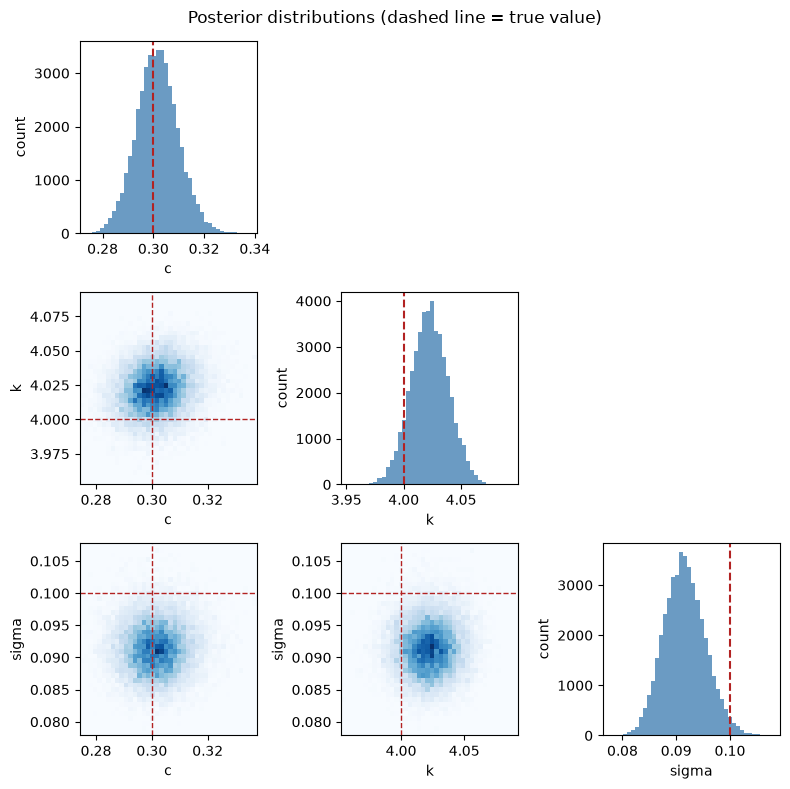

In [6]:
param_names = ['c', 'k', 'sigma']
truths = (true_params.c, true_params.k, config.sigma)
n_dim = 3

fig, axes = plt.subplots(n_dim, n_dim, figsize=(8, 8))
for i in range(n_dim):
    for j in range(n_dim):
        ax = axes[i, j]
        if i == j:
            ax.hist(samples[:, i], bins=40, color='steelblue', alpha=0.8)
            ax.axvline(truths[i], color='firebrick', ls='--', lw=1.5)
            # diagonal panels are 1D marginals: label both axes directly
            # so every panel (including the top-left one) is self-labeled
            ax.set_xlabel(param_names[i])
            ax.set_ylabel('count')
        elif i > j:
            ax.hist2d(samples[:, j], samples[:, i], bins=40, cmap='Blues')
            ax.axvline(truths[j], color='firebrick', ls='--', lw=1)
            ax.axhline(truths[i], color='firebrick', ls='--', lw=1)
            ax.set_xlabel(param_names[j])
            ax.set_ylabel(param_names[i])
        else:
            ax.axis('off')
fig.suptitle('Posterior distributions (dashed line = true value)')
plt.tight_layout()
plt.savefig('../figures/03_corner.png', dpi=150)
plt.show()

## Posterior predictive check

Trajectories drawn from posterior samples, overlaid on the noisy observations and the clean ground truth. This is the "does the fit actually explain the data" sanity check -- the spread of posterior draws should roughly bracket the scatter of the noisy points, not be much tighter (overconfident) or much looser (underfit) than it.

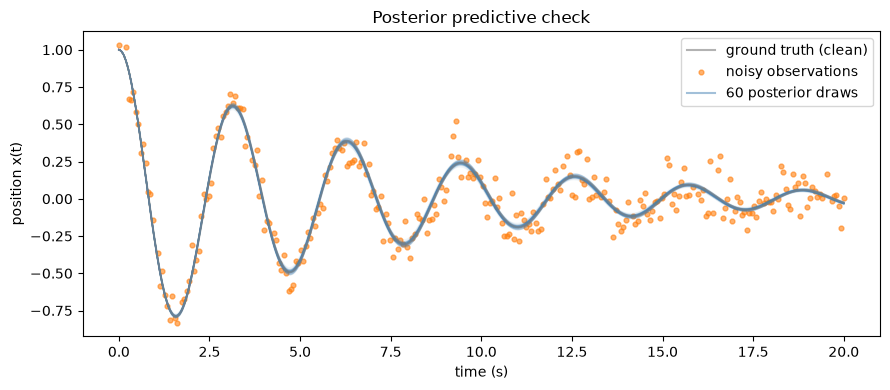

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
t_fine = np.linspace(t_obs.min(), t_obs.max(), 500)

idx = np.random.default_rng(1).choice(len(samples), size=60, replace=False)
for i in idx:
    c, k, sigma = samples[i]
    x_pred = forward_model(c, k, t_fine, x0, v0)
    ax.plot(t_fine, x_pred, color='steelblue', alpha=0.08, lw=1)

ax.plot(t, x_clean, label='ground truth (clean)', color='gray', alpha=0.6, linewidth=1.5)
ax.scatter(t_obs, x_obs, label='noisy observations', color='C1', s=12, alpha=0.6)
ax.plot([], [], color='steelblue', alpha=0.5, lw=1.5, label='60 posterior draws')
ax.set_xlabel('time (s)'); ax.set_ylabel('position x(t)')
ax.set_title('Posterior predictive check')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/03_posterior_predictive.png', dpi=150)
plt.show()

## Least-squares vs. MCMC: what the posterior adds

The point estimates end up close to each other (as they should -- both are fitting the same data), but least-squares stops there. MCMC gives a full 68% credible interval on each parameter.

In [8]:
c_med, k_med, sigma_med = np.median(samples, axis=0)
c_lo, c_hi = np.percentile(samples[:, 0], [16, 84])
k_lo, k_hi = np.percentile(samples[:, 1], [16, 84])

print(f"{'':>12} {'true':>10} {'least-squares':>16} {'MCMC median':>14} {'68% CI':>20}")
print(f"{'c':>12} {true_params.c:>10.4f} {c_ls:>16.4f} {c_med:>14.4f} [{c_lo:.4f}, {c_hi:.4f}]")
print(f"{'k':>12} {true_params.k:>10.4f} {k_ls:>16.4f} {k_med:>14.4f} [{k_lo:.4f}, {k_hi:.4f}]")

                   true    least-squares    MCMC median               68% CI
           c     0.3000           0.3009         0.3015 [0.2934, 0.3098]
           k     4.0000           4.0221         4.0223 [4.0060, 4.0387]


## Takeaways

- The MCMC posterior medians land close to the least-squares point estimates, as expected -- both fit the same underlying data -- but MCMC additionally gives a calibrated 68% credible interval on `c` and `k`, plus a jointly-inferred estimate of the measurement noise `sigma` itself.
- The trace plot shows the chain mixing well past the burn-in cutoff, with an acceptance fraction in the healthy 0.2-0.5 range -- confirming the hand-tuned `step_size` was reasonable, not too greedy and not too timid.
- The `c`-`k` corner plot shows the expected mild positive correlation: a bit more damping and a bit more stiffness can produce similar-looking trajectories, so the posterior isn't perfectly circular.
- Where this really pays off vs. notebook 02: at higher noise levels, the least-squares point estimate drifts with no indication of *how much* to trust it, while the MCMC credible intervals widen visibly -- an honest signal that the data is less informative, not just a number that happens to be less accurate.
- Trade-off vs. a fancier sampler: single-chain Metropolis-Hastings needed many more steps (50,000 vs. 3,000x32 walkers) to explore the correlated `(c, k)` posterior well, and required manually tuning `step_size` to hit a good acceptance fraction -- a fancier sampler (e.g. an ensemble/affine-invariant method, or `emcee` if available) automates that adaptation, but at the cost of being harder to fully explain and defend.
- As with notebook 02, `m` was fixed at 1 throughout for the same identifiability reason: position-only observations can't separate absolute mass from the `c/m`, `k/m` ratios that drive the dynamics.